In [1]:
import datetime
from typing import Iterator

import folium
import geopandas as gpd
import hvplot.pandas
import matplotlib.colors
import matplotlib.pyplot as plt
import movingpandas as mpd
import movingpandas.cpa
import numpy as np
import pandas as pd
import shapely
from tqdm.notebook import tqdm

# Closest point of approach example
This notebook demonstrates the CPA calculation for two trajectories. In maritime navigation, CPA stands for Closest Point of Approach. It is a concept used to assess the risk of collision between vessels. CPA refers to the minimum distance that will occur between two ships if they continue on their current courses and speeds. It is often calculated using data from the Automatic Identification System (AIS), which tracks vessel movements. Here the public Danish AIS dataset is used. 

There is an example where two ships meet on the evening of july 5th of 2017. The ships that approach eachother are MMSI: 265550210 and MMSI: 265410000. 

In [2]:
mmsi_a = 265550210
mmsi_b = 265410000

color_a = (0, 0.3, 0.3)
color_b = (0.3, 0, 0.3)
t_0 = datetime.datetime(2017, 7, 5, 19, 0, 0)
t_1 = datetime.datetime(2017, 7, 5, 19, 13, 55)


# we expect to find this as the closest point and interval of overlapping time window
expected = {
    "t": datetime.datetime(2017, 7, 5, 19, 8, 31),
    "p": shapely.Point(669670.780244901, 6397464.37325368),
    "q": shapely.Point(669566.587642144, 6397098.724455765),
    "t0_min": datetime.datetime(2017, 7, 5, 19, 0, 1),
    "t1_max": datetime.datetime(2017, 7, 5, 19, 13, 53),
}

# Read the data
Here we read the data from a geopackage file.  We convert the timestamps to a real date object. 
For visualisation purposes we add a variable `t_min_t_0` so that we can visualize the time since start of the trajectories. 
We convert the data to UTM 32N so that we can do our computations in Euclidean space, in meters.

We'll subset the data using the 2 ship identifiers and our time window of interest. 

In [3]:
ais_gdf = gpd.read_file("../data/ais.gpkg")
ais_gdf["t"] = pd.to_datetime(ais_gdf["Timestamp"], format="%d/%m/%Y %H:%M:%S")
ais_gdf["t_min_t_0"] = (ais_gdf["t"] - t_0).dt.total_seconds()

# convert to local UTM so we can do metric calculations
ais_gdf = ais_gdf.to_crs("EPSG:32632")
ais_gdf = ais_gdf.sort_values(["MMSI", "t"])

In [4]:
# Filter on MMSI of interest and time window of interest
ais_gdf = ais_gdf[
    np.logical_and.reduce(
        [
            ais_gdf["MMSI"].isin([mmsi_a, mmsi_b]),
            ais_gdf["t"] >= t_0,
            ais_gdf["t"] < t_1,
        ]
    )
]

# Convert to trajectories
Here we convert our data into trajectories. We'll extract the 2 trajectories as seperate trajectories. 
The CPA calculation uses a pair of trajectories as input. 

In [5]:
ais_gdf["traj_id"] = ais_gdf["MMSI"]
ais_gdf["obj_id"] = ais_gdf["MMSI"]
traj_collection = mpd.TrajectoryCollection(
    ais_gdf.set_index("t"), traj_id_col="traj_id", obj_id_col="obj_id", min_length=100
)
traj_collection.add_speed(overwrite=True, units=("m", "s"))
traj_collection.add_direction(overwrite=True)


traj_a = traj_collection.get_trajectory(mmsi_a)
traj_b = traj_collection.get_trajectory(mmsi_b)

# Visualisation
We'll create a visualization using the `hvplot` code from holoviews. This shows that the trajectories overlapped. 
But how close did the ships get to eachother? That is what we'll compute here. 

In [6]:
# create a variant in wgs84 to show a plot
traj_collection_wgs84 = mpd.TrajectoryCollection(
    ais_gdf.to_crs("EPSG:4326").set_index("t"),
    traj_id_col="traj_id",
    obj_id_col="obj_id",
    min_length=100,
)
# show trajectories with number of seconds since t_0
traj_collection_wgs84.hvplot(c="t_min_t_0", cmap="Blues")

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]   (t_min_t_0)
   .Points.I :Points   [Longitude,Latitude]   (t_min_t_0,triangle_angle)

# Calculate the CPA
Now we have the functions defined we can compute a dataframe of all the cpa calculations for each sequential time step pair in the timesteps of ship a and b. The table has a lot of variables that we'll probably remove. We'll probably keep the position of the closest point (actualy a line, pq), the distance (dist) and the time (t) and maybe the status or a code. 

In [7]:
cpa_calc = movingpandas.cpa.CPACalculator(traj_a, traj_b)
cpa_df = cpa_calc.segments_gdf()
cpa = cpa_calc.min()
cpa_df.sort_values("dist").head()

,t_at,t_to,geometry,dist,status
130,2017-07-05 19:08:31.892660226,0.654740,"LINESTRING (669670.78 6397464.373, 669566.588 ...",380.204079,approaching
131,2017-07-05 19:08:35.000000000,-3.393321,"LINESTRING (669676.948 6397452.972, 669547.789...",381.089295,diverging
129,2017-07-05 19:08:25.000000000,-22.385399,"LINESTRING (669659.084 6397485.995, 669608.109...",381.202006,diverging
128,2017-07-05 19:08:25.000000000,1.933643,"LINESTRING (669659.084 6397485.995, 669608.109...",381.202006,converging
132,2017-07-05 19:08:36.000000000,-0.540582,"LINESTRING (669678.62 6397449.419, 669541.74 6...",381.746013,diverging


# Visualisation
This visualization shows what has been computed. All the blue lines show the segments for which a CPA has been computed. 
Between these sets a red line was found (using interpolation) where the ships were closest to eachother (assuming their current course, so not just in distance).  This red line is what is referred to as the Closest Point of Approach. The distance was 380m and the time of this CPA was  2017-07-05 19:08:31. We'll also visualize the line of closest point of approach using a holoviews map.

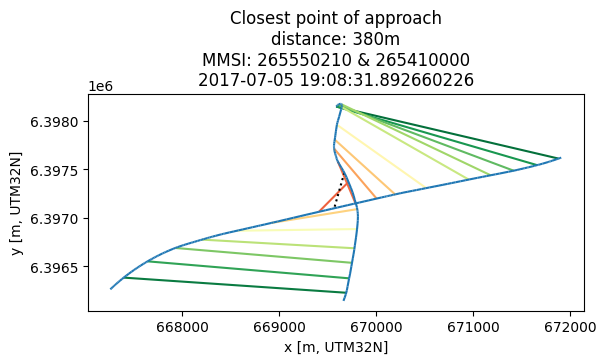

In [8]:
fig, ax = plt.subplots()

ax.set_xlabel("x [m, UTM32N]")
ax.set_ylabel("y [m, UTM32N]")
ax.set_title(
    f"Closest point of approach\ndistance: {cpa.dist:.0f}m\nMMSI: {mmsi_a} & {mmsi_b}\n{cpa.t_at}"
)

# compute colors ranging from
N = matplotlib.colors.Normalize(0, cpa_df["dist"].max())
cmap = matplotlib.cm.RdYlGn
colors = cmap(N(cpa_df["dist"]))
thin = 15
# don't show all the computed lines
cpa_df[::thin].plot(ax=ax, color=colors[::thin])
# show the computed closest point of approach
gpd.GeoSeries(cpa["geometry"]).plot(ax=ax, color="black", linestyle=":")
traj_a.plot(ax=ax)
traj_b.plot(ax=ax);

In [9]:
# We can alos add the Closest Point of Approach to our map.
cpa_wgs84 = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries(cpa["geometry"]), crs="EPSG:32632"
).to_crs("EPSG:3857")
# show trajectories with with CPA line
(
    traj_collection_wgs84.hvplot(c="t_min_t_0", cmap="Blues")
    * cpa_wgs84.hvplot(line_color=(0.8, 0.3, 0.3), line_width=3, line_alpha=0.8)
)

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]   (t_min_t_0)
   .Points.I :Points   [Longitude,Latitude]   (t_min_t_0,triangle_angle)
   .Path.II  :Path   [x,y]